In [1]:
import pandas as pd

In [3]:
# Load the GEDEvent dataset
df = pd.read_csv('GEDEvent_v25_1.csv')

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

C:\Users\moheb\AppData\Local\Temp\ipykernel_24612\3907581917.py:2: DtypeWarning: Columns (47) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('GEDEvent_v25_1.csv')


Dataset shape: (385918, 49)

Column names:
['id', 'relid', 'year', 'active_year', 'code_status', 'type_of_violence', 'conflict_dset_id', 'conflict_new_id', 'conflict_name', 'dyad_dset_id', 'dyad_new_id', 'dyad_name', 'side_a_dset_id', 'side_a_new_id', 'side_a', 'side_b_dset_id', 'side_b_new_id', 'side_b', 'number_of_sources', 'source_article', 'source_office', 'source_date', 'source_headline', 'source_original', 'where_prec', 'where_coordinates', 'where_description', 'adm_1', 'adm_2', 'latitude', 'longitude', 'geom_wkt', 'priogrid_gid', 'country', 'country_id', 'region', 'event_clarity', 'date_prec', 'date_start', 'date_end', 'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown', 'best', 'high', 'low', 'gwnoa', 'gwnob']


In [4]:
# Let's first see a few sample rows to understand the data structure
print("Sample of the data:")
print(df.head())

print("\nUnique countries (first 20):")
print(sorted(df['country'].unique())[:20])

Sample of the data:
       id               relid  year  active_year code_status   
0  244657  IRQ-2017-1-524-322  2017         True       Clear  \
1  412700  IRQ-2021-1-524-145  2021         True       Clear   
2  413023  IRQ-2021-1-524-143  2021         True       Clear   
3  412909  IRQ-2021-1-524-144  2021         True       Clear   
4  132140    AFG-1989-1-411-2  1989         True       Clear   

   type_of_violence  conflict_dset_id  conflict_new_id   
0                 1               259              259  \
1                 1               259              259   
2                 1               259              259   
3                 1               259              259   
4                 1               333              333   

             conflict_name  dyad_dset_id  ...    date_end deaths_a  deaths_b   
0         Iraq: Government           524  ...  2017-07-31        0         4  \
1         Iraq: Government           524  ...  2021-08-26       13         1   
2     

In [5]:
# Filter for Liberia conflicts from 1989 onwards
liberia_conflicts = df[(df['country'] == 'Liberia') & (df['year'] >= 1989)].copy()

print(f"Total conflicts in Liberia from 1989 onwards: {len(liberia_conflicts)}")
print(f"Years covered: {liberia_conflicts['year'].min()} - {liberia_conflicts['year'].max()}")
print(f"Unique conflict names: {liberia_conflicts['conflict_name'].nunique()}")

Total conflicts in Liberia from 1989 onwards: 551
Years covered: 1989 - 2024
Unique conflict names: 18


In [6]:
# Show unique conflict names and their frequencies
print("Conflict names and frequency:")
conflict_counts = liberia_conflicts['conflict_name'].value_counts()
print(conflict_counts)
print("\n" + "="*50 + "\n")

# Show conflicts by year
print("Conflicts by year:")
yearly_counts = liberia_conflicts.groupby('year').size()
print(yearly_counts)

Conflict names and frequency:
conflict_name
NPFL - Civilians                         127
Liberia: Government                      118
Government of Liberia - Civilians         80
LPC - Civilians                           56
ULIMO - K - Civilians                     33
ULIMO - Civilians                         22
LURD - Civilians                          21
NPFL - ULIMO                              20
NPFL, ULIMO - K - AFL, LPC, ULIMO - J     16
INPFL - Civilians                         16
LPC - NPFL                                12
ULIMO - J - Civilians                     11
ULIMO - J - ULIMO - K                      6
LDF - Civilians                            5
INPFL - NPFL                               5
Guinea: Government                         1
Sierra Leone: Government                   1
RUF - ULIMO                                1
Name: count, dtype: int64


Conflicts by year:
year
1989      6
1990    138
1991     19
1992     26
1993     47
1994     92
1995     52
1996     3

In [7]:
# Show detailed breakdown with parties involved
print("Detailed conflict information:")
print("="*60)

# Group by conflict name and show additional details
for conflict in conflict_counts.index[:10]:  # Top 10 conflicts
    conflict_data = liberia_conflicts[liberia_conflicts['conflict_name'] == conflict]
    years_active = f"{conflict_data['year'].min()}-{conflict_data['year'].max()}"
    total_deaths = conflict_data['best'].sum()
    
    print(f"\nConflict: {conflict}")
    print(f"  Years active: {years_active}")
    print(f"  Number of events: {len(conflict_data)}")
    print(f"  Total estimated deaths: {total_deaths}")
    
    # Show unique side_a and side_b combinations
    parties = conflict_data[['side_a', 'side_b']].drop_duplicates()
    if len(parties) <= 3:
        print(f"  Parties involved:")
        for _, row in parties.iterrows():
            side_a = row['side_a'] if pd.notna(row['side_a']) else 'Unknown'
            side_b = row['side_b'] if pd.notna(row['side_b']) else 'Civilians/Unknown'
            print(f"    {side_a} vs {side_b}")

Detailed conflict information:

Conflict: NPFL - Civilians
  Years active: 1989-1996
  Number of events: 127
  Total estimated deaths: 6019
  Parties involved:
    NPFL vs Civilians

Conflict: Liberia: Government
  Years active: 1989-2003
  Number of events: 118
  Total estimated deaths: 3043

Conflict: Government of Liberia - Civilians
  Years active: 1989-2024
  Number of events: 80
  Total estimated deaths: 4240
  Parties involved:
    Government of Liberia vs Civilians

Conflict: LPC - Civilians
  Years active: 1993-1996
  Number of events: 56
  Total estimated deaths: 2228
  Parties involved:
    LPC vs Civilians

Conflict: ULIMO - K - Civilians
  Years active: 1994-1996
  Number of events: 33
  Total estimated deaths: 1403
  Parties involved:
    ULIMO - K vs Civilians

Conflict: ULIMO - Civilians
  Years active: 1992-1993
  Number of events: 22
  Total estimated deaths: 1258
  Parties involved:
    ULIMO vs Civilians

Conflict: LURD - Civilians
  Years active: 2001-2003
  Number

In [8]:
# Summary statistics and timeline
print("\n" + "="*70)
print("SUMMARY OF LIBERIAN CONFLICTS (1989-2024)")
print("="*70)

total_deaths = liberia_conflicts['best'].sum()
civilian_deaths = liberia_conflicts['deaths_civilians'].sum()
total_events = len(liberia_conflicts)

print(f"Total conflict events: {total_events}")
print(f"Total estimated deaths: {total_deaths:,}")
print(f"Civilian deaths: {civilian_deaths:,}")
print(f"Years of conflict: {liberia_conflicts['year'].nunique()}")

print(f"\nMajor conflict periods:")
print("1989-1997: First Liberian Civil War")
print("1999-2003: Second Liberian Civil War") 
print("2019-2024: Post-conflict incidents")

# Show the most deadly individual events
print(f"\nMost deadly single events:")
deadly_events = liberia_conflicts.nlargest(5, 'best')[['date_start', 'conflict_name', 'best', 'where_description']]
for idx, event in deadly_events.iterrows():
    date = event['date_start'] if pd.notna(event['date_start']) else 'Unknown date'
    location = event['where_description'] if pd.notna(event['where_description']) else 'Unknown location'
    print(f"  {date}: {event['conflict_name']} - {event['best']} deaths ({location})")


SUMMARY OF LIBERIAN CONFLICTS (1989-2024)
Total conflict events: 551
Total estimated deaths: 23,234
Civilian deaths: 17,842
Years of conflict: 18

Major conflict periods:
1989-1997: First Liberian Civil War
1999-2003: Second Liberian Civil War
2019-2024: Post-conflict incidents

Most deadly single events:
  1996-04-06: NPFL, ULIMO - K - AFL, LPC, ULIMO - J - 1647 deaths (Monrovia city, Greater Monrovia district, Montserrado county)
  1996-12-28: ULIMO - J - Civilians - 1000 deaths (Tubmanburg town, Klay district, Bomi county)
  1994-01-01: ULIMO - K - Civilians - 1000 deaths (Naama town, Zota district, Bong county)
  1990-08-01: NPFL - Civilians - 900 deaths (Marshal town, Mambah-Kaba district, Margibi county)
  2003-07-18: Liberia: Government - 809 deaths (Monrovia city, Greater Monrovia district, Montserrado county)


In [9]:
# Key actors and factions
print("\n" + "="*70)
print("KEY ACTORS IN LIBERIAN CONFLICTS (1989-2024)")
print("="*70)

# Extract all unique actors from side_a and side_b
actors_a = set(liberia_conflicts['side_a'].dropna().unique())
actors_b = set(liberia_conflicts['side_b'].dropna().unique())
all_actors = actors_a.union(actors_b)

# Remove generic terms and focus on armed groups
armed_groups = [actor for actor in all_actors if actor not in ['Civilians', 'Unknown']]

print("Armed Groups and Factions:")
for actor in sorted(armed_groups):
    events_as_a = len(liberia_conflicts[liberia_conflicts['side_a'] == actor])
    events_as_b = len(liberia_conflicts[liberia_conflicts['side_b'] == actor])
    total_events = events_as_a + events_as_b
    if total_events > 0:
        print(f"  {actor}: {total_events} conflict events")

# Explanation of acronyms
print(f"\nKey Acronyms:")
print("  NPFL: National Patriotic Front of Liberia (Charles Taylor's faction)")
print("  INPFL: Independent National Patriotic Front of Liberia (Prince Johnson's faction)")
print("  AFL: Armed Forces of Liberia (Government forces)")
print("  ULIMO: United Liberation Movement of Liberia for Democracy")
print("  ULIMO-K: ULIMO - Krahn faction")
print("  ULIMO-J: ULIMO - Jallah faction") 
print("  LPC: Liberia Peace Council")
print("  LURD: Liberians United for Reconciliation and Democracy")
print("  LDF: Lofa Defense Force")


KEY ACTORS IN LIBERIAN CONFLICTS (1989-2024)
Armed Groups and Factions:
  AFL, LPC, ULIMO - J: 16 conflict events
  Government of Guinea: 1 conflict events
  Government of Liberia: 198 conflict events
  Government of Sierra Leone: 1 conflict events
  INPFL: 35 conflict events
  LDF: 5 conflict events
  LPC: 68 conflict events
  LURD: 88 conflict events
  MODEL: 6 conflict events
  NPFL: 195 conflict events
  NPFL, ULIMO - K: 16 conflict events
  RFDG: 1 conflict events
  RUF: 2 conflict events
  ULIMO: 43 conflict events
  ULIMO - J: 17 conflict events
  ULIMO - K: 39 conflict events

Key Acronyms:
  NPFL: National Patriotic Front of Liberia (Charles Taylor's faction)
  INPFL: Independent National Patriotic Front of Liberia (Prince Johnson's faction)
  AFL: Armed Forces of Liberia (Government forces)
  ULIMO: United Liberation Movement of Liberia for Democracy
  ULIMO-K: ULIMO - Krahn faction
  ULIMO-J: ULIMO - Jallah faction
  LPC: Liberia Peace Council
  LURD: Liberians United for R

In [12]:
# Create a comprehensive time table of all Liberian conflicts
print("ALL LIBERIAN CONFLICTS (1989-2024) - CHRONOLOGICAL TABLE")
print("="*80)

# Select relevant columns and sort by date
liberia_table = liberia_conflicts[['year', 'date_start', 'conflict_name', 'side_a', 'side_b', 
                                 'best', 'deaths_civilians', 'where_description']].copy()

# Sort by year and date
liberia_table = liberia_table.sort_values(['year', 'date_start'])

# Display settings for pandas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None) 
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

print(f"\nTotal events: {len(liberia_table)}")
print(f"Displaying all {len(liberia_table)} events:\n")

# Display the table
# display(liberia_table)

ALL LIBERIAN CONFLICTS (1989-2024) - CHRONOLOGICAL TABLE

Total events: 551
Displaying all 551 events:



In [11]:
# Filter for First Liberian Civil War (1989-1997)
print("\n" + "="*80)
print("FIRST LIBERIAN CIVIL WAR (1989-1997) - DETAILED TABLE")
print("="*80)

# Filter for the first civil war period
first_civil_war = liberia_conflicts[(liberia_conflicts['year'] >= 1989) & 
                                   (liberia_conflicts['year'] <= 1997)].copy()

# Select and sort the same columns
first_war_table = first_civil_war[['year', 'date_start', 'conflict_name', 'side_a', 'side_b', 
                                  'best', 'deaths_civilians', 'where_description']].copy()
first_war_table = first_war_table.sort_values(['year', 'date_start'])

print(f"\nFirst Civil War Statistics:")
print(f"Total events: {len(first_war_table)}")
print(f"Years covered: {first_war_table['year'].min()} - {first_war_table['year'].max()}")
print(f"Total deaths: {first_war_table['best'].sum():,}")
print(f"Civilian deaths: {first_war_table['deaths_civilians'].sum():,}")
print(f"Peak year: {first_war_table['year'].value_counts().index[0]} ({first_war_table['year'].value_counts().iloc[0]} events)")

print(f"\nDisplaying all {len(first_war_table)} events from First Civil War:\n")

# Display the filtered table
display(first_war_table)


FIRST LIBERIAN CIVIL WAR (1989-1997) - DETAILED TABLE

First Civil War Statistics:
Total events: 414
Years covered: 1989 - 1997
Total deaths: 17,025
Civilian deaths: 13,791
Peak year: 1990 (138 events)

Displaying all 414 events from First Civil War:



,year,date_start,conflict_name,side_a,side_b,best,deaths_civilians,where_description
153564,1989,1989-12-01,NPFL - Civilians,NPFL,Civilians,7,7,"Tiaplay town, Zoegeh district, Nimba county"
153365,1989,1989-12-24,Liberia: Government,Government of Liberia,NPFL,16,0,"Butuo town (near), Zoegeh district, Nimba county"
153366,1989,1989-12-24,Liberia: Government,Government of Liberia,NPFL,2,0,"Butuo town, Zoegeh district, Nimba county"
153367,1989,1989-12-25,Liberia: Government,Government of Liberia,NPFL,6,0,"Butuo town (near), Zoegeh district, Nimba county"
153368,1989,1989-12-26,Liberia: Government,Government of Liberia,NPFL,3,0,"Loguatuo town (Zali), Gbehlageh district, Nimb..."
153484,1989,1989-12-28,Government of Liberia - Civilians,Government of Liberia,Civilians,11,11,"Butuo town, Zoegeh district, Nimba county"
153369,1990,1990-01-01,Liberia: Government,Government of Liberia,NPFL,1,0,"Senewen town (near), Gbarzon district, Grand G..."
153370,1990,1990-01-01,Liberia: Government,Government of Liberia,NPFL,1,0,"Karnplay town, Gbehlageh district, Nimba County"
153371,1990,1990-01-01,Liberia: Government,Government of Liberia,NPFL,3,0,"Karnplay town, Gbehlageh district, Nimba County"
153485,1990,1990-01-01,Government of Liberia - Civilians,Government of Liberia,Civilians,2,2,"Karnplay town, Gbehlageh district, Nimba County"


In [13]:
# Summary by year for First Civil War
print("\n" + "="*80)
print("FIRST LIBERIAN CIVIL WAR - YEARLY SUMMARY")
print("="*80)

# Create yearly summary
yearly_summary = first_civil_war.groupby('year').agg({
    'id': 'count',  # number of events
    'best': 'sum',  # total deaths
    'deaths_civilians': 'sum',  # civilian deaths
    'conflict_name': lambda x: x.value_counts().index[0]  # most common conflict type
}).rename(columns={
    'id': 'Events',
    'best': 'Total_Deaths', 
    'deaths_civilians': 'Civilian_Deaths',
    'conflict_name': 'Main_Conflict_Type'
})

print("Year-by-year breakdown of the First Liberian Civil War:\n")
display(yearly_summary)

# Show major factions by period
print("\n" + "="*60)
print("MAJOR FACTIONS BY PERIOD")
print("="*60)

periods = {
    "1989-1990: War Begins": first_civil_war[first_civil_war['year'].isin([1989, 1990])],
    "1991-1993: ULIMO Emerges": first_civil_war[first_civil_war['year'].isin([1991, 1992, 1993])],
    "1994-1996: Faction Fighting": first_civil_war[first_civil_war['year'].isin([1994, 1995, 1996])],
    "1997: War Ends": first_civil_war[first_civil_war['year'] == 1997]
}

for period_name, period_data in periods.items():
    print(f"\n{period_name}:")
    main_conflicts = period_data['conflict_name'].value_counts().head(3)
    total_events = len(period_data)
    total_deaths = period_data['best'].sum()
    print(f"  Events: {total_events}, Deaths: {total_deaths:,}")
    print("  Main conflicts:")
    for conflict, count in main_conflicts.items():
        print(f"    - {conflict}: {count} events")


FIRST LIBERIAN CIVIL WAR - YEARLY SUMMARY
Year-by-year breakdown of the First Liberian Civil War:



,Events,Total_Deaths,Civilian_Deaths,Main_Conflict_Type
year,,,,
1989,6,45,18,Liberia: Government
1990,138,3729,3388,NPFL - Civilians
1991,19,578,272,NPFL - Civilians
1992,26,453,410,NPFL - Civilians
1993,47,2673,2563,ULIMO - Civilians
1994,92,4167,3733,LPC - Civilians
1995,52,2290,2282,LPC - Civilians
1996,31,3077,1112,"NPFL, ULIMO - K - AFL, LPC, ULIMO - J"
1997,3,13,13,Government of Liberia - Civilians



MAJOR FACTIONS BY PERIOD

1989-1990: War Begins:
  Events: 144, Deaths: 3,774
  Main conflicts:
    - NPFL - Civilians: 46 events
    - Liberia: Government: 45 events
    - Government of Liberia - Civilians: 36 events

1991-1993: ULIMO Emerges:
  Events: 92, Deaths: 3,704
  Main conflicts:
    - NPFL - Civilians: 35 events
    - ULIMO - Civilians: 22 events
    - NPFL - ULIMO: 20 events

1994-1996: Faction Fighting:
  Events: 175, Deaths: 9,534
  Main conflicts:
    - LPC - Civilians: 52 events
    - NPFL - Civilians: 46 events
    - ULIMO - K - Civilians: 33 events

1997: War Ends:
  Events: 3, Deaths: 13
  Main conflicts:
    - Government of Liberia - Civilians: 2 events
    - ULIMO - J - Civilians: 1 events


In [14]:
# Filter for Sierra Leone Civil War (1991-2002)
print("\n" + "="*80)
print("SIERRA LEONE CIVIL WAR (1991-2002) - DETAILED TABLE")
print("="*80)

# Filter for Sierra Leone conflicts during the civil war period
sierra_leone_civil_war = df[(df['country'] == 'Sierra Leone') & 
                           (df['year'] >= 1991) & 
                           (df['year'] <= 2002)].copy()

# Select and sort the same columns as the Liberia table
sierra_leone_table = sierra_leone_civil_war[['year', 'date_start', 'conflict_name', 'side_a', 'side_b', 
                                           'best', 'deaths_civilians', 'where_description']].copy()
sierra_leone_table = sierra_leone_table.sort_values(['year', 'date_start'])

print(f"\nSierra Leone Civil War Statistics:")
print(f"Total events: {len(sierra_leone_table)}")
print(f"Years covered: {sierra_leone_table['year'].min()} - {sierra_leone_table['year'].max()}")
print(f"Total deaths: {sierra_leone_table['best'].sum():,}")
print(f"Civilian deaths: {sierra_leone_table['deaths_civilians'].sum():,}")
if len(sierra_leone_table) > 0:
    print(f"Peak year: {sierra_leone_table['year'].value_counts().index[0]} ({sierra_leone_table['year'].value_counts().iloc[0]} events)")

print(f"\nDisplaying all {len(sierra_leone_table)} events from Sierra Leone Civil War:\n")

# Display the filtered table
display(sierra_leone_table)


SIERRA LEONE CIVIL WAR (1991-2002) - DETAILED TABLE

Sierra Leone Civil War Statistics:
Total events: 1496
Years covered: 1991 - 2002
Total deaths: 20,443
Civilian deaths: 9,667
Peak year: 1998 (360 events)

Displaying all 1496 events from Sierra Leone Civil War:



,year,date_start,conflict_name,side_a,side_b,best,deaths_civilians,where_description
226300,1991,1991-03-01,NPFL - Civilians,NPFL,Civilians,3,3,"Sulima town, Pujehun district, Southern province"
226311,1991,1991-03-20,RUF - Civilians,RUF,Civilians,60,60,Koindu town
225547,1991,1991-03-23,Sierra Leone: Government,Government of Sierra Leone,RUF,2,0,Bomaru town
226312,1991,1991-03-23,RUF - Civilians,RUF,Civilians,0,0,Kailahun district (Sienga town)
226313,1991,1991-03-23,RUF - Civilians,RUF,Civilians,0,0,Bomaru town
225548,1991,1991-03-26,Sierra Leone: Government,Government of Sierra Leone,RUF,20,0,Potoru town
225549,1991,1991-03-26,Sierra Leone: Government,Government of Sierra Leone,RUF,20,0,Bo district (Futa Pujeh town)
225550,1991,1991-03-26,Sierra Leone: Government,Government of Sierra Leone,RUF,20,0,Dandabu town
225551,1991,1991-03-27,Sierra Leone: Government,Government of Sierra Leone,RUF,1,0,Buedu town
225552,1991,1991-03-28,Sierra Leone: Government,Government of Sierra Leone,RUF,17,0,Koindu town


In [15]:
# Summary by year for Sierra Leone Civil War
print("\n" + "="*80)
print("SIERRA LEONE CIVIL WAR - YEARLY SUMMARY")
print("="*80)

# Create yearly summary
sl_yearly_summary = sierra_leone_civil_war.groupby('year').agg({
    'id': 'count',  # number of events
    'best': 'sum',  # total deaths
    'deaths_civilians': 'sum',  # civilian deaths
    'conflict_name': lambda x: x.value_counts().index[0]  # most common conflict type
}).rename(columns={
    'id': 'Events',
    'best': 'Total_Deaths', 
    'deaths_civilians': 'Civilian_Deaths',
    'conflict_name': 'Main_Conflict_Type'
})

print("Year-by-year breakdown of the Sierra Leone Civil War:\n")
display(sl_yearly_summary)

# Show key conflicts and factions
print("\n" + "="*80)
print("KEY CONFLICTS IN SIERRA LEONE CIVIL WAR")
print("="*80)

print("Most frequent conflict types:")
sl_conflict_counts = sierra_leone_civil_war['conflict_name'].value_counts()
for conflict, count in sl_conflict_counts.head(8).items():
    print(f"  {conflict}: {count} events")

# Show major factions by period
print("\n" + "="*60)
print("MAJOR FACTIONS BY PERIOD")
print("="*60)

sl_periods = {
    "1991-1995: Early War": sierra_leone_civil_war[sierra_leone_civil_war['year'].isin([1991, 1992, 1993, 1994, 1995])],
    "1996-1997: AFRC Coup": sierra_leone_civil_war[sierra_leone_civil_war['year'].isin([1996, 1997])],
    "1998-2000: ECOMOG & UN": sierra_leone_civil_war[sierra_leone_civil_war['year'].isin([1998, 1999, 2000])],
    "2001-2002: War Ends": sierra_leone_civil_war[sierra_leone_civil_war['year'].isin([2001, 2002])]
}

for period_name, period_data in sl_periods.items():
    print(f"\n{period_name}:")
    main_conflicts = period_data['conflict_name'].value_counts().head(3)
    total_events = len(period_data)
    total_deaths = period_data['best'].sum()
    print(f"  Events: {total_events}, Deaths: {total_deaths:,}")
    print("  Main conflicts:")
    for conflict, count in main_conflicts.items():
        print(f"    - {conflict}: {count} events")


SIERRA LEONE CIVIL WAR - YEARLY SUMMARY
Year-by-year breakdown of the Sierra Leone Civil War:



,Events,Total_Deaths,Civilian_Deaths,Main_Conflict_Type
year,,,,
1991,128,1225,700,RUF - Civilians
1992,64,531,329,RUF - Civilians
1993,68,642,237,Sierra Leone: Government
1994,164,2097,1551,RUF - Civilians
1995,197,3194,1851,RUF - Civilians
1996,100,943,414,RUF - Civilians
1997,137,1233,616,Sierra Leone: Government
1998,360,5155,1872,Sierra Leone: Government
1999,199,4493,1527,Sierra Leone: Government



KEY CONFLICTS IN SIERRA LEONE CIVIL WAR
Most frequent conflict types:
  Sierra Leone: Government: 629 events
  RUF - Civilians: 533 events
  AFRC - Civilians: 164 events
  Government of Sierra Leone - Civilians: 118 events
  Kamajors - Civilians: 17 events
  NPFL - Civilians: 10 events
  Kamajors - RUF: 6 events
  Government of Nigeria - Civilians: 5 events

MAJOR FACTIONS BY PERIOD

1991-1995: Early War:
  Events: 621, Deaths: 7,689
  Main conflicts:
    - RUF - Civilians: 331 events
    - Sierra Leone: Government: 243 events
    - Government of Sierra Leone - Civilians: 19 events

1996-1997: AFRC Coup:
  Events: 237, Deaths: 2,176
  Main conflicts:
    - Sierra Leone: Government: 97 events
    - RUF - Civilians: 69 events
    - Government of Sierra Leone - Civilians: 59 events

1998-2000: ECOMOG & UN:
  Events: 618, Deaths: 10,504
  Main conflicts:
    - Sierra Leone: Government: 277 events
    - AFRC - Civilians: 164 events
    - RUF - Civilians: 131 events

2001-2002: War Ends:
  

In [16]:
# Import plotting libraries
import matplotlib.pyplot as plt
import numpy as np

# Create data for both conflicts (1989-2002)
years = list(range(1989, 2003))  # 1989-2002 inclusive

# Prepare Liberia data for the full time range
liberia_data_full = df[(df['country'] == 'Liberia') & 
                      (df['year'] >= 1989) & 
                      (df['year'] <= 2002)].copy()

# Prepare Sierra Leone data for the full time range  
sierra_leone_data_full = df[(df['country'] == 'Sierra Leone') & 
                           (df['year'] >= 1989) & 
                           (df['year'] <= 2002)].copy()

print("Data Summary for Visualization:")
print(f"Liberia events (1989-2002): {len(liberia_data_full)}")
print(f"Sierra Leone events (1989-2002): {len(sierra_leone_data_full)}")
print(f"Liberia years with data: {sorted(liberia_data_full['year'].unique())}")
print(f"Sierra Leone years with data: {sorted(sierra_leone_data_full['year'].unique())}")

Data Summary for Visualization:
Liberia events (1989-2002): 494
Sierra Leone events (1989-2002): 1496
Liberia years with data: [1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002]
Sierra Leone years with data: [1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002]


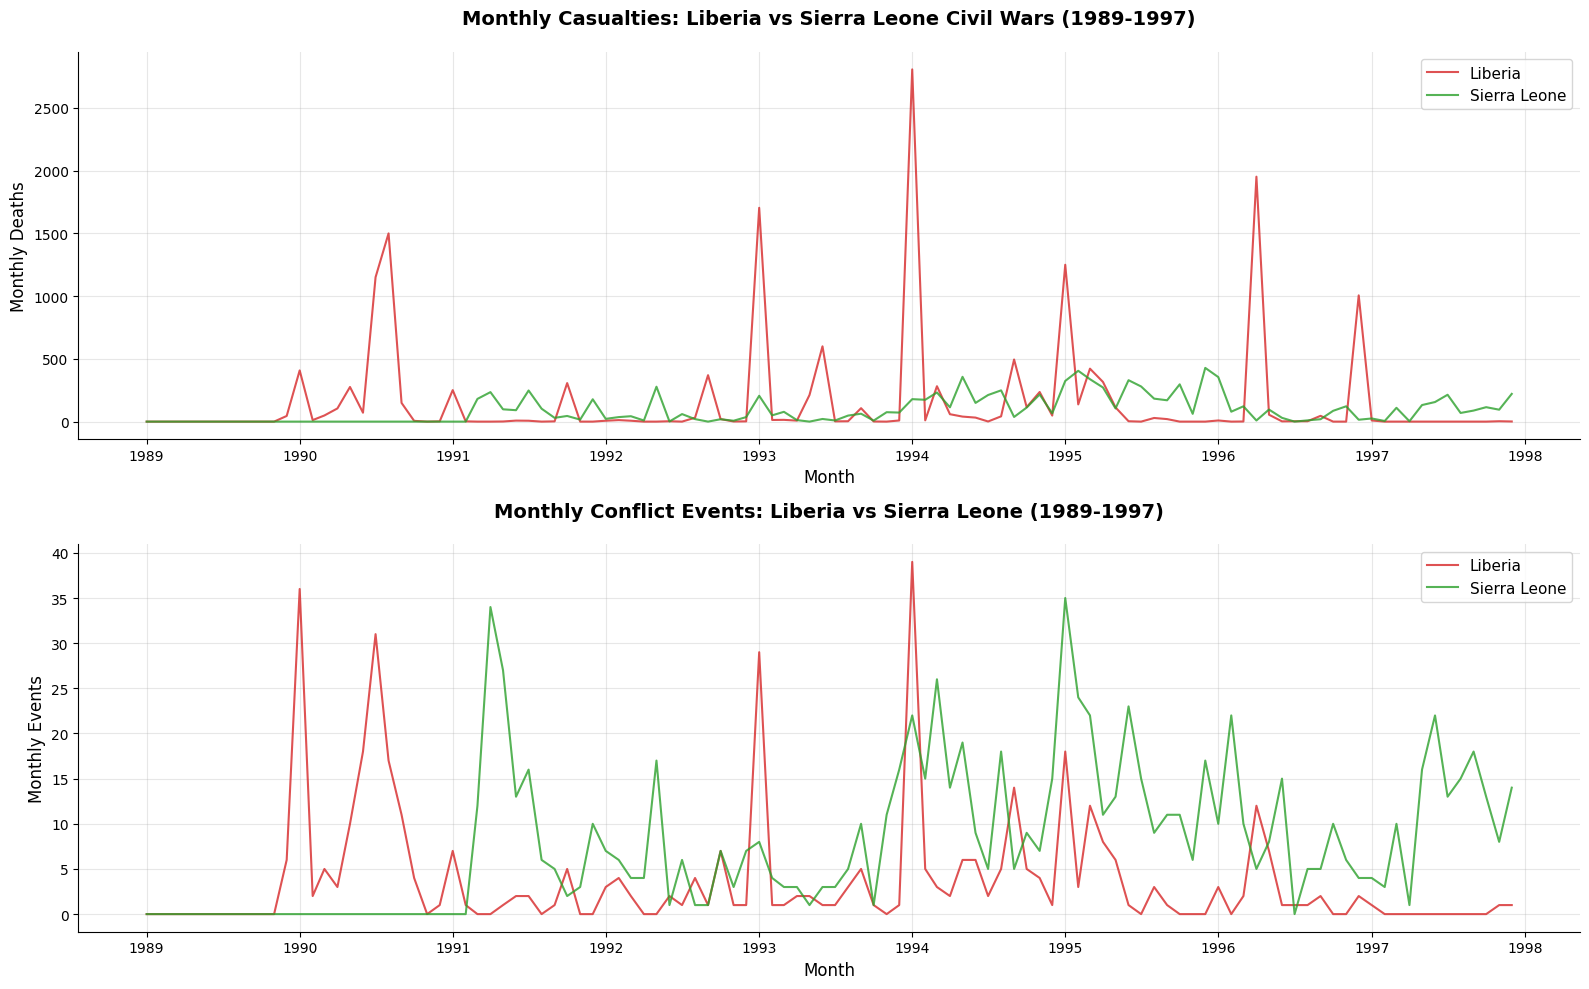


MONTHLY TIMELINE SUMMARY (1989-1997)
Total months analyzed: 108
Liberia: 17,025 deaths, 414 events
Sierra Leone: 9,865 deaths, 858 events

Peak casualty months:
Liberia: 1994-01 (2807 deaths)
Sierra Leone: 1995-12 (428 deaths)


In [22]:
# Prepare monthly data for both countries (1989-1997 First Liberian Civil War period)
import datetime as dt

# Filter data for 1989-1997 period only
liberia_first_war = df[(df['country'] == 'Liberia') & 
                      (df['year'] >= 1989) & 
                      (df['year'] <= 1997)].copy()

sierra_leone_first_period = df[(df['country'] == 'Sierra Leone') & 
                               (df['year'] >= 1991) & 
                               (df['year'] <= 1997)].copy()

# Convert date_start to datetime and extract year-month
liberia_first_war['date_start'] = pd.to_datetime(liberia_first_war['date_start'], errors='coerce')
sierra_leone_first_period['date_start'] = pd.to_datetime(sierra_leone_first_period['date_start'], errors='coerce')

# Create year-month period for grouping
liberia_first_war['year_month'] = liberia_first_war['date_start'].dt.to_period('M')
sierra_leone_first_period['year_month'] = sierra_leone_first_period['date_start'].dt.to_period('M')

# Create complete monthly timeline from 1989-01 to 1997-12
start_period = pd.Period('1989-01', 'M')
end_period = pd.Period('1997-12', 'M')
all_months = pd.period_range(start=start_period, end=end_period, freq='M')

# Group by month and sum data
liberia_monthly = liberia_first_war.groupby('year_month').agg({
    'best': 'sum',
    'id': 'count'
}).rename(columns={'best': 'deaths', 'id': 'events'}).reindex(all_months, fill_value=0)

sierra_leone_monthly = sierra_leone_first_period.groupby('year_month').agg({
    'best': 'sum', 
    'id': 'count'
}).rename(columns={'best': 'deaths', 'id': 'events'}).reindex(all_months, fill_value=0)

# Convert periods to datetime for plotting
month_dates = [period.to_timestamp() for period in all_months]

# Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Total Casualties per Month
ax1.plot(month_dates, liberia_monthly['deaths'], linewidth=1.5, 
         label='Liberia', color='#d62728', alpha=0.8)
ax1.plot(month_dates, sierra_leone_monthly['deaths'], linewidth=1.5, 
         label='Sierra Leone', color='#2ca02c', alpha=0.8)

ax1.set_title('Monthly Casualties: Liberia vs Sierra Leone Civil Wars (1989-1997)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Month', fontsize=12)
ax1.set_ylabel('Monthly Deaths', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Format x-axis to show years
from matplotlib.dates import YearLocator, DateFormatter
ax1.xaxis.set_major_locator(YearLocator())
ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
ax1.tick_params(axis='x', rotation=0)

# Add some styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Number of Conflict Events per Month
ax2.plot(month_dates, liberia_monthly['events'], linewidth=1.5, 
         label='Liberia', color='#d62728', alpha=0.8)
ax2.plot(month_dates, sierra_leone_monthly['events'], linewidth=1.5, 
         label='Sierra Leone', color='#2ca02c', alpha=0.8)

ax2.set_title('Monthly Conflict Events: Liberia vs Sierra Leone (1989-1997)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Month', fontsize=12)
ax2.set_ylabel('Monthly Events', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Format x-axis to show years
ax2.xaxis.set_major_locator(YearLocator())
ax2.xaxis.set_major_formatter(DateFormatter('%Y'))
ax2.tick_params(axis='x', rotation=0)

# Add some styling
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Show peak months summary
print(f"\nMONTHLY TIMELINE SUMMARY (1989-1997)")
print("="*60)
print(f"Total months analyzed: {len(all_months)}")
print(f"Liberia: {liberia_monthly['deaths'].sum():,} deaths, {liberia_monthly['events'].sum()} events")
print(f"Sierra Leone: {sierra_leone_monthly['deaths'].sum():,} deaths, {sierra_leone_monthly['events'].sum()} events")

# Find peak months
liberia_peak_month = liberia_monthly['deaths'].idxmax()
sierra_leone_peak_month = sierra_leone_monthly['deaths'].idxmax()

print(f"\nPeak casualty months:")
print(f"Liberia: {liberia_peak_month} ({liberia_monthly.loc[liberia_peak_month, 'deaths']} deaths)")
print(f"Sierra Leone: {sierra_leone_peak_month} ({sierra_leone_monthly.loc[sierra_leone_peak_month, 'deaths']} deaths)")

ORIGINAL YEARLY TIMELINE (1989-2002)


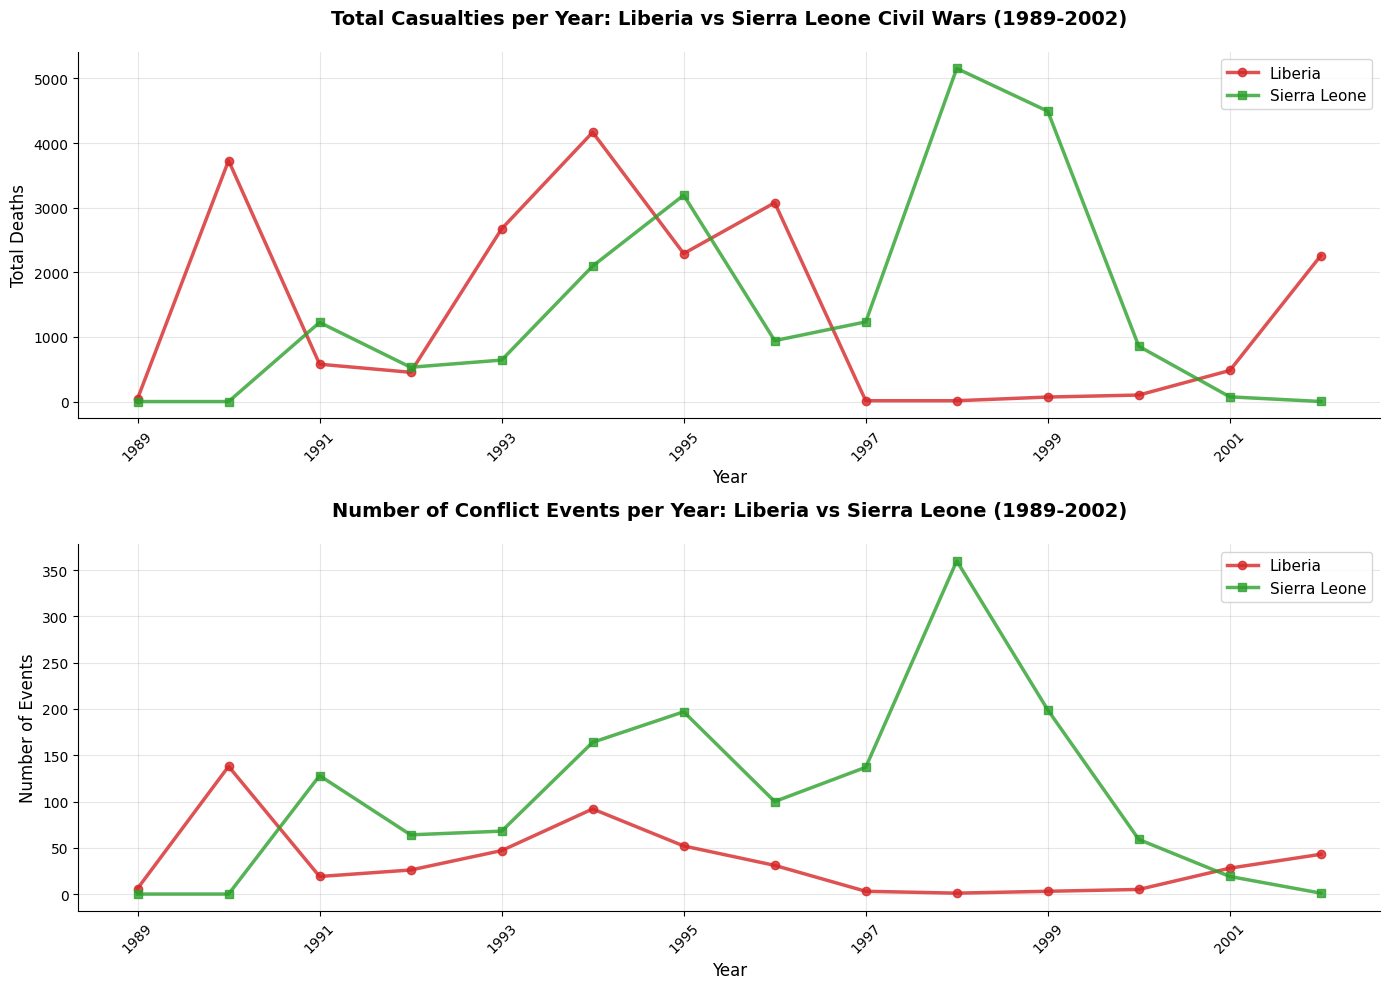


YEARLY TIMELINE SUMMARY (1989-2002)
Liberia: 19,949 deaths, 494 events
Sierra Leone: 20,443 deaths, 1496 events

Peak years:
Liberia: 1994 (4,167 deaths)
Sierra Leone: 1998 (5,155 deaths)


In [23]:
# Original yearly timeline plot (1989-2002)
print("ORIGINAL YEARLY TIMELINE (1989-2002)")
print("="*50)

# Prepare yearly data for both countries (1989-2002)
liberia_yearly_deaths = []
liberia_yearly_events = []
sierra_leone_yearly_deaths = []
sierra_leone_yearly_events = []

for year in years:
    # Liberia data
    liberia_year_data = liberia_data_full[liberia_data_full['year'] == year]
    liberia_yearly_deaths.append(liberia_year_data['best'].sum())
    liberia_yearly_events.append(len(liberia_year_data))
    
    # Sierra Leone data
    sl_year_data = sierra_leone_data_full[sierra_leone_data_full['year'] == year]
    sierra_leone_yearly_deaths.append(sl_year_data['best'].sum())
    sierra_leone_yearly_events.append(len(sl_year_data))

# Create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Total Casualties per Year
ax1.plot(years, liberia_yearly_deaths, marker='o', linewidth=2.5, markersize=6, 
         label='Liberia', color='#d62728', alpha=0.8)
ax1.plot(years, sierra_leone_yearly_deaths, marker='s', linewidth=2.5, markersize=6, 
         label='Sierra Leone', color='#2ca02c', alpha=0.8)

ax1.set_title('Total Casualties per Year: Liberia vs Sierra Leone Civil Wars (1989-2002)', 
              fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Deaths', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_xticks(years[::2])  # Show every other year
ax1.tick_params(axis='x', rotation=45)

# Add some styling
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Plot 2: Number of Conflict Events per Year (News Mentions)
ax2.plot(years, liberia_yearly_events, marker='o', linewidth=2.5, markersize=6, 
         label='Liberia', color='#d62728', alpha=0.8)
ax2.plot(years, sierra_leone_yearly_events, marker='s', linewidth=2.5, markersize=6, 
         label='Sierra Leone', color='#2ca02c', alpha=0.8)

ax2.set_title('Number of Conflict Events per Year: Liberia vs Sierra Leone (1989-2002)', 
              fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Events', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_xticks(years[::2])  # Show every other year
ax2.tick_params(axis='x', rotation=45)

# Add some styling
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

print(f"\nYEARLY TIMELINE SUMMARY (1989-2002)")
print("="*50)
print(f"Liberia: {sum(liberia_yearly_deaths):,} deaths, {sum(liberia_yearly_events)} events")
print(f"Sierra Leone: {sum(sierra_leone_yearly_deaths):,} deaths, {sum(sierra_leone_yearly_events)} events")

print(f"\nPeak years:")
liberia_peak_year = years[liberia_yearly_deaths.index(max(liberia_yearly_deaths))]
sierra_leone_peak_year = years[sierra_leone_yearly_deaths.index(max(sierra_leone_yearly_deaths))]
print(f"Liberia: {liberia_peak_year} ({max(liberia_yearly_deaths):,} deaths)")
print(f"Sierra Leone: {sierra_leone_peak_year} ({max(sierra_leone_yearly_deaths):,} deaths)")

NORMALIZED TIMELINE: AVERAGE CASUALTIES PER EVENT (1989-2002)


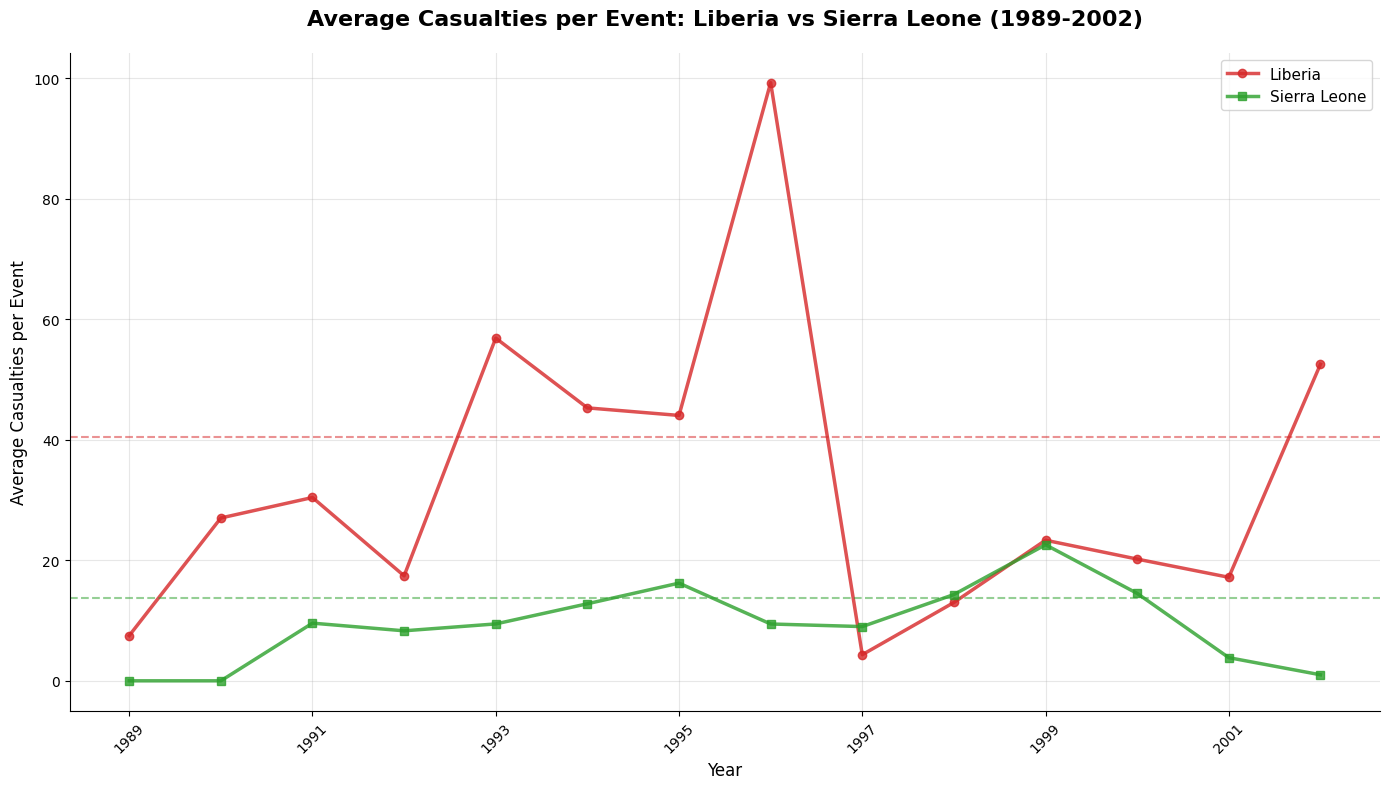


NORMALIZED ANALYSIS (Average Casualties per Event)
Overall averages:
  Liberia: 40.4 casualties per event
  Sierra Leone: 13.7 casualties per event

Peak intensity years (deadliest events on average):
  Liberia: 1996 (99.3 casualties per event)
  Sierra Leone: 1999 (22.6 casualties per event)

Intensity comparison:
  Liberia least deadly events: 1997 (4.3 casualties per event)
  Sierra Leone least deadly events: 2002 (1.0 casualties per event)

Key Insights:
  • Liberian conflict events were 3.0x more deadly on average
  • This normalization removes the bias of raw event counts
  • Shows the actual lethality/intensity of individual conflict incidents


In [24]:
# Normalized timeline: Casualties per Event Ratio (1989-2002)
print("NORMALIZED TIMELINE: AVERAGE CASUALTIES PER EVENT (1989-2002)")
print("="*65)

# Calculate casualties per event ratio for each year
liberia_casualties_per_event = []
sierra_leone_casualties_per_event = []

for year in years:
    # Liberia data
    lib_deaths = liberia_yearly_deaths[year - 1989]  # Adjust for list indexing
    lib_events = liberia_yearly_events[year - 1989]
    lib_ratio = lib_deaths / lib_events if lib_events > 0 else 0
    liberia_casualties_per_event.append(lib_ratio)
    
    # Sierra Leone data  
    sl_deaths = sierra_leone_yearly_deaths[year - 1989]
    sl_events = sierra_leone_yearly_events[year - 1989]
    sl_ratio = sl_deaths / sl_events if sl_events > 0 else 0
    sierra_leone_casualties_per_event.append(sl_ratio)

# Create the normalized plot
fig, ax = plt.subplots(1, 1, figsize=(14, 8))

# Plot normalized casualties per event
ax.plot(years, liberia_casualties_per_event, marker='o', linewidth=2.5, markersize=6, 
        label='Liberia', color='#d62728', alpha=0.8)
ax.plot(years, sierra_leone_casualties_per_event, marker='s', linewidth=2.5, markersize=6, 
        label='Sierra Leone', color='#2ca02c', alpha=0.8)

ax.set_title('Average Casualties per Event: Liberia vs Sierra Leone (1989-2002)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Average Casualties per Event', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(years[::2])  # Show every other year
ax.tick_params(axis='x', rotation=45)

# Add some styling
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add horizontal line for reference
overall_liberia_avg = sum(liberia_yearly_deaths) / sum(liberia_yearly_events)
overall_sl_avg = sum(sierra_leone_yearly_deaths) / sum(sierra_leone_yearly_events)
ax.axhline(y=overall_liberia_avg, color='#d62728', linestyle='--', alpha=0.5, 
           label=f'Liberia Overall Avg: {overall_liberia_avg:.1f}')
ax.axhline(y=overall_sl_avg, color='#2ca02c', linestyle='--', alpha=0.5,
           label=f'Sierra Leone Overall Avg: {overall_sl_avg:.1f}')

plt.tight_layout()
plt.show()

# Analysis of the normalized data
print(f"\nNORMALIZED ANALYSIS (Average Casualties per Event)")
print("="*55)

# Find peak intensity years
lib_peak_intensity_year = years[liberia_casualties_per_event.index(max(liberia_casualties_per_event))]
sl_peak_intensity_year = years[sierra_leone_casualties_per_event.index(max(sierra_leone_casualties_per_event))]

print(f"Overall averages:")
print(f"  Liberia: {overall_liberia_avg:.1f} casualties per event")
print(f"  Sierra Leone: {overall_sl_avg:.1f} casualties per event")

print(f"\nPeak intensity years (deadliest events on average):")
print(f"  Liberia: {lib_peak_intensity_year} ({max(liberia_casualties_per_event):.1f} casualties per event)")
print(f"  Sierra Leone: {sl_peak_intensity_year} ({max(sierra_leone_casualties_per_event):.1f} casualties per event)")

# Show years with highest and lowest intensity
print(f"\nIntensity comparison:")
active_lib_years = [(years[i], liberia_casualties_per_event[i]) for i in range(len(years)) 
                   if liberia_yearly_events[i] > 0]
active_sl_years = [(years[i], sierra_leone_casualties_per_event[i]) for i in range(len(years)) 
                  if sierra_leone_yearly_events[i] > 0]

if active_lib_years:
    lib_min_year, lib_min_intensity = min(active_lib_years, key=lambda x: x[1])
    print(f"  Liberia least deadly events: {lib_min_year} ({lib_min_intensity:.1f} casualties per event)")
    
if active_sl_years:
    sl_min_year, sl_min_intensity = min(active_sl_years, key=lambda x: x[1])
    print(f"  Sierra Leone least deadly events: {sl_min_year} ({sl_min_intensity:.1f} casualties per event)")

print(f"\nKey Insights:")
if overall_liberia_avg > overall_sl_avg:
    print(f"  • Liberian conflict events were {overall_liberia_avg/overall_sl_avg:.1f}x more deadly on average")
else:
    print(f"  • Sierra Leone conflict events were {overall_sl_avg/overall_liberia_avg:.1f}x more deadly on average")
print(f"  • This normalization removes the bias of raw event counts")
print(f"  • Shows the actual lethality/intensity of individual conflict incidents")

In [25]:
# Export timeline data to CSV files
print("EXPORTING TIMELINE DATA TO CSV FILES")
print("="*45)

# 1. Create comprehensive yearly timeline CSV
yearly_timeline_data = {
    'Year': years,
    'Liberia_Total_Deaths': liberia_yearly_deaths,
    'Liberia_Total_Events': liberia_yearly_events,
    'Liberia_Casualties_Per_Event': liberia_casualties_per_event,
    'Sierra_Leone_Total_Deaths': sierra_leone_yearly_deaths,
    'Sierra_Leone_Total_Events': sierra_leone_yearly_events,  
    'Sierra_Leone_Casualties_Per_Event': sierra_leone_casualties_per_event
}

yearly_timeline_df = pd.DataFrame(yearly_timeline_data)

# Add additional calculated columns
yearly_timeline_df['Total_Deaths_Both_Countries'] = (yearly_timeline_df['Liberia_Total_Deaths'] + 
                                                    yearly_timeline_df['Sierra_Leone_Total_Deaths'])
yearly_timeline_df['Total_Events_Both_Countries'] = (yearly_timeline_df['Liberia_Total_Events'] + 
                                                    yearly_timeline_df['Sierra_Leone_Total_Events'])

# Export yearly data
yearly_filename = 'liberia_sierra_leone_yearly_timeline_1989_2002.csv'
yearly_timeline_df.to_csv(yearly_filename, index=False)
print(f"✓ Exported yearly timeline: {yearly_filename}")

# 2. Create monthly timeline CSV (1989-1997)
monthly_timeline_data = {
    'Year_Month': [str(period) for period in all_months],
    'Year': [period.year for period in all_months],
    'Month': [period.month for period in all_months],
    'Liberia_Monthly_Deaths': liberia_monthly['deaths'].values,
    'Liberia_Monthly_Events': liberia_monthly['events'].values,
    'Sierra_Leone_Monthly_Deaths': sierra_leone_monthly['deaths'].values,
    'Sierra_Leone_Monthly_Events': sierra_leone_monthly['events'].values
}

monthly_timeline_df = pd.DataFrame(monthly_timeline_data)

# Add calculated columns for monthly data
monthly_timeline_df['Liberia_Casualties_Per_Event_Monthly'] = [
    deaths/events if events > 0 else 0 
    for deaths, events in zip(monthly_timeline_df['Liberia_Monthly_Deaths'], 
                             monthly_timeline_df['Liberia_Monthly_Events'])
]

monthly_timeline_df['Sierra_Leone_Casualties_Per_Event_Monthly'] = [
    deaths/events if events > 0 else 0 
    for deaths, events in zip(monthly_timeline_df['Sierra_Leone_Monthly_Deaths'], 
                             monthly_timeline_df['Sierra_Leone_Monthly_Events'])
]

monthly_timeline_df['Total_Deaths_Both_Monthly'] = (monthly_timeline_df['Liberia_Monthly_Deaths'] + 
                                                   monthly_timeline_df['Sierra_Leone_Monthly_Deaths'])
monthly_timeline_df['Total_Events_Both_Monthly'] = (monthly_timeline_df['Liberia_Monthly_Events'] + 
                                                   monthly_timeline_df['Sierra_Leone_Monthly_Events'])

# Export monthly data
monthly_filename = 'liberia_sierra_leone_monthly_timeline_1989_1997.csv'
monthly_timeline_df.to_csv(monthly_filename, index=False)
print(f"✓ Exported monthly timeline: {monthly_filename}")

# 3. Create summary statistics CSV
summary_stats = {
    'Metric': [
        'Total Deaths (1989-2002)',
        'Total Events (1989-2002)', 
        'Overall Casualties per Event',
        'Peak Deaths Year',
        'Peak Deaths Count',
        'Peak Events Year', 
        'Peak Events Count',
        'Peak Intensity Year (Casualties per Event)',
        'Peak Intensity Value',
        'Most Active Period',
        'Deadliest Single Month (1989-1997)',
        'Deadliest Single Month Deaths'
    ],
    'Liberia': [
        sum(liberia_yearly_deaths),
        sum(liberia_yearly_events),
        f"{overall_liberia_avg:.1f}",
        liberia_peak_year,
        max(liberia_yearly_deaths),
        years[liberia_yearly_events.index(max(liberia_yearly_events))],
        max(liberia_yearly_events),
        lib_peak_intensity_year,
        f"{max(liberia_casualties_per_event):.1f}",
        "1989-1997 (First Civil War)",
        str(liberia_peak_month),
        liberia_monthly.loc[liberia_peak_month, 'deaths']
    ],
    'Sierra_Leone': [
        sum(sierra_leone_yearly_deaths),
        sum(sierra_leone_yearly_events),
        f"{overall_sl_avg:.1f}",
        sierra_leone_peak_year,
        max(sierra_leone_yearly_deaths),
        years[sierra_leone_yearly_events.index(max(sierra_leone_yearly_events))],
        max(sierra_leone_yearly_events),
        sl_peak_intensity_year,
        f"{max(sierra_leone_casualties_per_event):.1f}",
        "1991-2002 (Continuous conflict)",
        str(sierra_leone_peak_month),
        sierra_leone_monthly.loc[sierra_leone_peak_month, 'deaths']
    ]
}

summary_df = pd.DataFrame(summary_stats)

# Export summary statistics
summary_filename = 'liberia_sierra_leone_conflict_summary.csv'
summary_df.to_csv(summary_filename, index=False)
print(f"✓ Exported summary statistics: {summary_filename}")

# Display preview of the files
print(f"\n" + "="*55)
print("CSV FILES CREATED - PREVIEW")
print("="*55)

print(f"\n1. YEARLY TIMELINE ({yearly_filename}):")
print(yearly_timeline_df.head(10))

print(f"\n2. MONTHLY TIMELINE ({monthly_filename}) - First 12 months:")
print(monthly_timeline_df.head(12))

print(f"\n3. SUMMARY STATISTICS ({summary_filename}):")
print(summary_df)

print(f"\n" + "="*55)
print("FILES READY FOR DOWNLOAD")
print("="*55)
print(f"📊 {yearly_filename} - Complete yearly data (1989-2002)")
print(f"📅 {monthly_filename} - Detailed monthly data (1989-1997)")  
print(f"📈 {summary_filename} - Key statistics and comparisons")
print(f"\nAll files are saved in the current directory.")

EXPORTING TIMELINE DATA TO CSV FILES
✓ Exported yearly timeline: liberia_sierra_leone_yearly_timeline_1989_2002.csv
✓ Exported monthly timeline: liberia_sierra_leone_monthly_timeline_1989_1997.csv
✓ Exported summary statistics: liberia_sierra_leone_conflict_summary.csv

CSV FILES CREATED - PREVIEW

1. YEARLY TIMELINE (liberia_sierra_leone_yearly_timeline_1989_2002.csv):
   Year  Liberia_Total_Deaths  Liberia_Total_Events   
0  1989                    45                     6  \
1  1990                  3729                   138   
2  1991                   578                    19   
3  1992                   453                    26   
4  1993                  2673                    47   
5  1994                  4167                    92   
6  1995                  2290                    52   
7  1996                  3077                    31   
8  1997                    13                     3   
9  1998                    13                     1   

   Liberia_Casualties

In [18]:
# Summary statistics and key insights
print("="*80)
print("COMPARATIVE ANALYSIS: LIBERIA vs SIERRA LEONE CIVIL WARS (1989-2002)")
print("="*80)

# Create comparison dataframe
comparison_data = {
    'Year': years,
    'Liberia_Deaths': liberia_yearly_deaths,
    'Liberia_Events': liberia_yearly_events,
    'Sierra_Leone_Deaths': sierra_leone_yearly_deaths,
    'Sierra_Leone_Events': sierra_leone_yearly_events
}

comparison_df = pd.DataFrame(comparison_data)
print("\nDetailed Year-by-Year Comparison:")
display(comparison_df)

# Key insights
print("\n" + "="*60)
print("KEY INSIGHTS FROM THE CHARTS:")
print("="*60)

liberia_peak_deaths_year = years[liberia_yearly_deaths.index(max(liberia_yearly_deaths))]
sl_peak_deaths_year = years[sierra_leone_yearly_deaths.index(max(sierra_leone_yearly_deaths))]
liberia_peak_events_year = years[liberia_yearly_events.index(max(liberia_yearly_events))]
sl_peak_events_year = years[sierra_leone_yearly_events.index(max(sierra_leone_yearly_events))]

print(f"\n1. PEAK CASUALTY YEARS:")
print(f"   Liberia: {liberia_peak_deaths_year} ({max(liberia_yearly_deaths):,} deaths)")
print(f"   Sierra Leone: {sl_peak_deaths_year} ({max(sierra_leone_yearly_deaths):,} deaths)")

print(f"\n2. PEAK ACTIVITY YEARS:")
print(f"   Liberia: {liberia_peak_events_year} ({max(liberia_yearly_events)} events)")
print(f"   Sierra Leone: {sl_peak_events_year} ({max(sierra_leone_yearly_events)} events)")

print(f"\n3. CONFLICT TIMELINES:")
print(f"   Liberia: Active 1989-1997 (First Civil War), resumed 2001-2003 (Second Civil War)")
print(f"   Sierra Leone: Active 1991-2002 (continuous conflict)")

print(f"\n4. TOTAL IMPACT (1989-2002):")
print(f"   Liberia: {sum(liberia_yearly_deaths):,} deaths, {sum(liberia_yearly_events)} events")
print(f"   Sierra Leone: {sum(sierra_leone_yearly_deaths):,} deaths, {sum(sierra_leone_yearly_events)} events")

print(f"\n5. REGIONAL SPILLOVER:")
print(f"   Both conflicts influenced each other, with cross-border activity")
print(f"   Sierra Leone conflict more sustained and had higher media documentation")

COMPARATIVE ANALYSIS: LIBERIA vs SIERRA LEONE CIVIL WARS (1989-2002)

Detailed Year-by-Year Comparison:


,Year,Liberia_Deaths,Liberia_Events,Sierra_Leone_Deaths,Sierra_Leone_Events
0,1989,45,6,0,0
1,1990,3729,138,0,0
2,1991,578,19,1225,128
3,1992,453,26,531,64
4,1993,2673,47,642,68
5,1994,4167,92,2097,164
6,1995,2290,52,3194,197
7,1996,3077,31,943,100
8,1997,13,3,1233,137
9,1998,13,1,5155,360



KEY INSIGHTS FROM THE CHARTS:

1. PEAK CASUALTY YEARS:
   Liberia: 1994 (4,167 deaths)
   Sierra Leone: 1998 (5,155 deaths)

2. PEAK ACTIVITY YEARS:
   Liberia: 1990 (138 events)
   Sierra Leone: 1998 (360 events)

3. CONFLICT TIMELINES:
   Liberia: Active 1989-1997 (First Civil War), resumed 2001-2003 (Second Civil War)
   Sierra Leone: Active 1991-2002 (continuous conflict)

4. TOTAL IMPACT (1989-2002):
   Liberia: 19,949 deaths, 494 events
   Sierra Leone: 20,443 deaths, 1496 events

5. REGIONAL SPILLOVER:
   Both conflicts influenced each other, with cross-border activity
   Sierra Leone conflict more sustained and had higher media documentation
